In [ ]:
import json
import re
from pathlib import Path

def transition_to_filename(transition, suffix=""):
    if not isinstance(transition, str):
        transition = str(transition)
    safe = re.sub(r"[^\d\-\[\],]+", "_", transition).strip("_")
    safe = safe.replace("[", "(").replace("]", ")")
    return f"{safe}{suffix}.txt"

def load_arrays_for_transition(saved_dir, transition):
    saved_dir = Path(saved_dir)
    filename = transition_to_filename(transition)
    path = saved_dir / filename

    if not path.exists():
        raise FileNotFoundError(f"No saved file for transition {transition}. Expected: {path}")

    data = json.loads(path.read_text(encoding="utf-8"))

    exp_wait_times = data["exp_wait_times_us"]
    exp_phases_pm1 = data["exp_phases_pm1"]

    return exp_wait_times, exp_phases_pm1, path

# ---- example usage ----
saved_dir = "Uncompensated_Phase_Data"
saved_dir = "Compensated_Phase_Data"
transition = "[[0, 4, 1], [0, 2, 0]]"  # can also pass eval(...) list

exp_wait_times, exp_phases_pm1, file_path = load_arrays_for_transition(saved_dir, transition)

print("Loaded from:", file_path)
print("exp_wait_times length:", len(exp_wait_times))
print("exp_phases_pm1 length:", len(exp_phases_pm1))

Loaded from: Uncompensated_Phase_Data\((0,_4,_1),_(0,_2,_0)).txt
exp_wait_times length: 14
exp_phases_pm1 length: 14


In [56]:
print(exp_phases_pm1)
print(exp_wait_times)

[0.010059653523388556, 0.121775777700442, 0.6085300502057063, 1.031366928012683, 1.6962415664778596, 1.9686584231526307, 2.1109230349411736, 2.1714395055712568, 2.236087730173635, 2.753398325325682, 3.085618301941267, 3.7102556511189495, 3.860669831953051, 3.979999999999998]
[0.0, 2133.0, 4267.0, 6400.0, 8533.0, 10667.0, 12800.0, 14933.0, 17067.0, 21333.0, 23467.0, 25600.0, 27733.0, 29867.0]


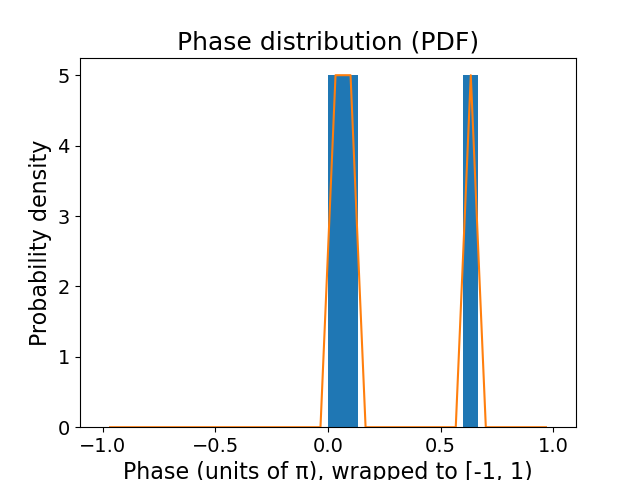

In [57]:
import numpy as np


phases = np.asarray(exp_phases_pm1, dtype=float)
phase_range = (-1, 1)
bins = 30

counts, edges = np.histogram(phases, bins=bins, range=phase_range, density=False)
bin_widths = np.diff(edges)
pdf = counts / (counts.sum() * bin_widths)   # integrates to ~1 over range
centers = (edges[:-1] + edges[1:]) / 2

plt.figure()
plt.hist(phases, bins=bins, range=phase_range, density=True)
# plt.xlabel("Phase (units of π), wrapped to [-1, 1)")
# plt.ylabel("Probability density" if density else "Count")
# plt.title("Phase histogram")
# plt.show()

# optional plot
import matplotlib.pyplot as plt
# plt.figure()
plt.plot(centers, pdf)
plt.xlabel("Phase (units of π), wrapped to [-1, 1)")
plt.ylabel("Probability density")
plt.title("Phase distribution (PDF)")
plt.show()

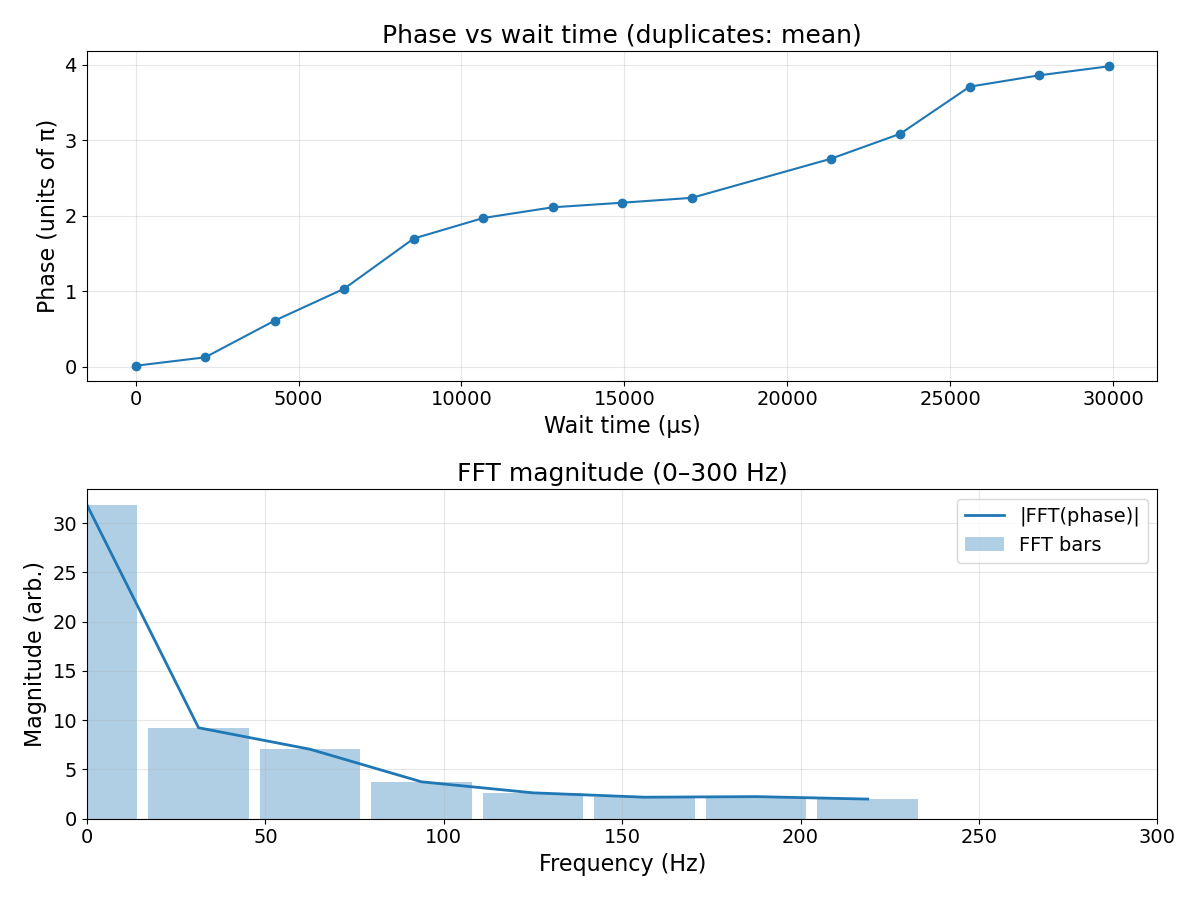

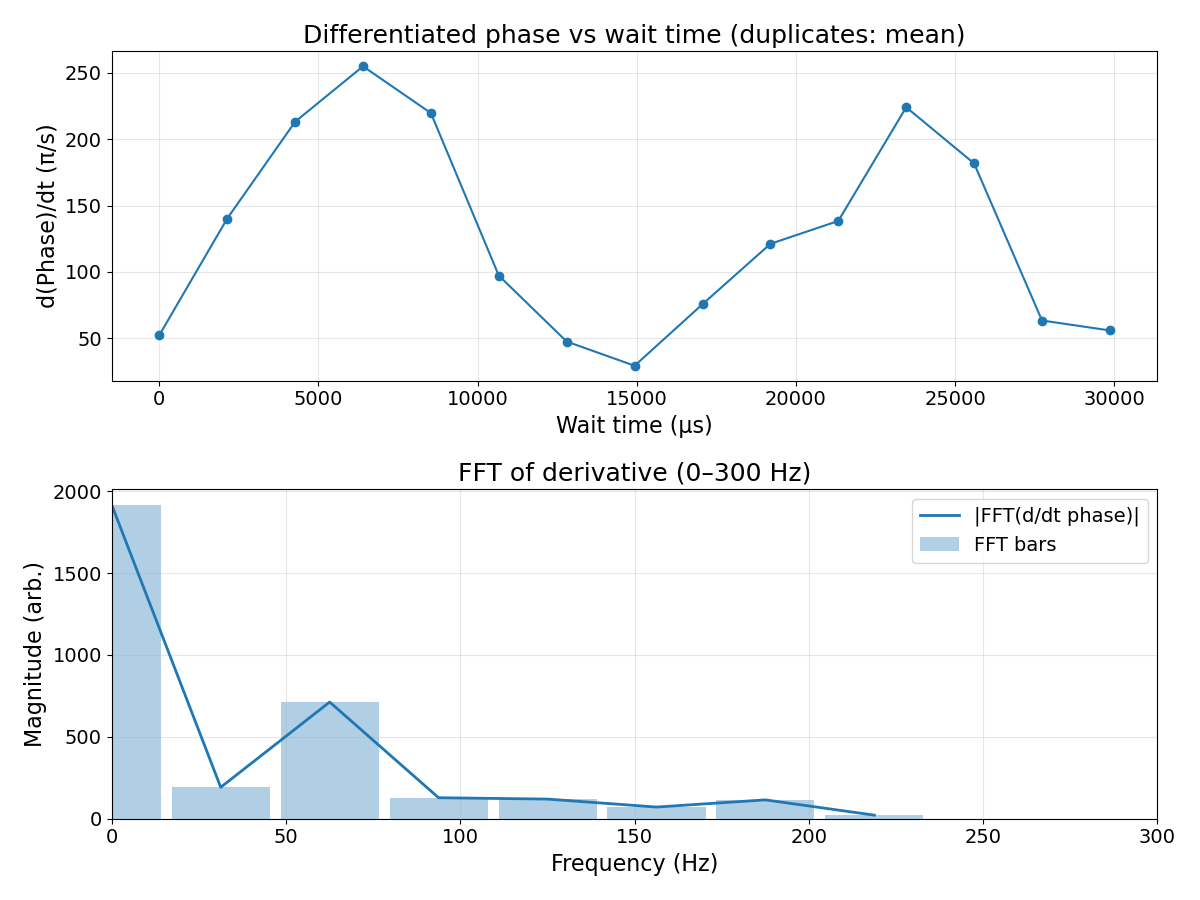

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def combine_duplicate_times(t_us, y, method="mean"):
    """
    Combine multiple y values that share the same time t_us.
    method: "mean" or "median"
    """
    t_us = np.asarray(t_us, dtype=float)
    y = np.asarray(y, dtype=float)

    idx = np.argsort(t_us)
    t_us = t_us[idx]
    y = y[idx]

    uniq_t, inv = np.unique(t_us, return_inverse=True)

    y_out = np.zeros_like(uniq_t, dtype=float)
    if method == "mean":
        counts = np.zeros_like(uniq_t, dtype=float)
        np.add.at(y_out, inv, y)
        np.add.at(counts, inv, 1.0)
        y_out = y_out / counts
    elif method == "median":
        # median needs a python loop (still fast enough for typical sizes)
        for i in range(len(uniq_t)):
            y_out[i] = np.median(y[inv == i])
    else:
        raise ValueError("method must be 'mean' or 'median'")

    return uniq_t, y_out


def plot_time_and_fft(
    exp_wait_times_us,
    exp_phases_pm1,
    fmax=300.0,
    take_derivative=False,
    combine_method="mean",   # <- NEW
    fig_size=(12, 9),
    font_size=16,
):
    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 2,
        "ytick.labelsize": font_size - 2,
        "legend.fontsize": font_size - 2,
    })

    # 1) combine duplicates
    t_us_u, y_u = combine_duplicate_times(exp_wait_times_us, exp_phases_pm1, method=combine_method)

    if len(t_us_u) < 2:
        raise ValueError("Need at least 2 unique time points after combining duplicates.")

    # 2) build uniform grid for FFT
    t_s = t_us_u * 1e-6
    diffs = np.diff(t_s)
    diffs = diffs[diffs > 0]  # drop zeros (shouldn't exist now, but safe)
    if diffs.size == 0:
        raise ValueError("Time array has no positive spacing.")
    dt = np.median(diffs)

    t_uniform = np.arange(t_s[0], t_s[-1] + dt/2, dt)
    y_uniform = np.interp(t_uniform, t_s, y_u)

    # 3) optionally differentiate on uniform grid
    if take_derivative:
        y_proc = np.gradient(y_uniform, dt)  # π/s
        top_y = y_proc
        top_ylabel = "d(Phase)/dt (π/s)"
        top_title = f"Differentiated phase vs wait time (duplicates: {combine_method})"
        fft_label = "|FFT(d/dt phase)|"
        fft_title = f"FFT of derivative (0–{fmax:g} Hz)"
    else:
        y_proc = y_uniform
        top_y = y_u
        top_ylabel = "Phase (units of π)"
        top_title = f"Phase vs wait time (duplicates: {combine_method})"
        fft_label = "|FFT(phase)|"
        fft_title = f"FFT magnitude (0–{fmax:g} Hz)"

    # remove mean (DC)
    y_fft = y_proc - 0*np.mean(y_proc)

    freqs = np.fft.rfftfreq(len(y_fft), d=dt)
    mag = np.abs(np.fft.rfft(y_fft))

    # limit FFT display
    mask = freqs <= fmax
    freqs = freqs[mask]
    mag = mag[mask]

    # 4) plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=fig_size)

    # Top plot (use unique times)
    if take_derivative:
        ax1.plot(t_uniform * 1e6, top_y, marker="o", linestyle="-")
    else:
        ax1.plot(t_us_u, top_y, marker="o", linestyle="-")

    ax1.set_xlabel("Wait time (µs)")
    ax1.set_ylabel(top_ylabel)
    ax1.set_title(top_title)
    ax1.grid(True, alpha=0.3)

    # FFT bars + line
    if len(freqs) > 1:
        df = np.median(np.diff(freqs))
        bar_width = 0.9 * df
    else:
        bar_width = 1.0

    ax2.bar(freqs, mag, width=bar_width, alpha=0.35, align="center", label="FFT bars")
    ax2.plot(freqs, mag, linewidth=2, label=fft_label)
    ax2.set_xlim(0, fmax)
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Magnitude (arb.)")
    ax2.set_title(fft_title)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


# usage:
plot_time_and_fft(exp_wait_times, exp_phases_pm1, fmax=300, take_derivative=False, combine_method="mean")
plot_time_and_fft(exp_wait_times, exp_phases_pm1, fmax=300, take_derivative=True,  combine_method="mean")

In [22]:
%matplotlib widget